- In this notebook, we will compare the Three types of Gradient Descent

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
# import the dataset
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
X = df[['Age','EstimatedSalary']]
y = df.iloc[:,-1]
print(X.shape)
print(y.shape)

(400, 2)
(400,)


In [8]:
# Let us Scale the X data
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler()
scaled.set_output(transform='pandas')
X_scaled = scaled.fit_transform(X)


In [9]:
# Let us now Make Neural Network
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(10 , activation = 'relu' , input_dim = 2))
model.add(tf.keras.layers.Dense(10 , activation = 'relu'))
model.add(tf.keras.layers.Dense(1 , activation = 'sigmoid'))

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='binary_crossentropy' , optimizer='Adam' , metrics = ['accuracy'])

In [32]:
# Now (i) Which Gradient Descent is Faster? -> Batch GD
import time
start = time.time()
history_batch = model.fit(X_scaled , y , epochs = 500 , batch_size = 400, validation_split = 0.2) # using batch GD
print(time.time() - start)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9094 - loss: 0.2054 - val_accuracy: 0.9500 - val_loss: 0.2124
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9125 - loss: 0.2053 - val_accuracy: 0.9500 - val_loss: 0.2126
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9125 - loss: 0.2052 - val_accuracy: 0.9500 - val_loss: 0.2128
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9125 - loss: 0.2051 - val_accuracy: 0.9500 - val_loss: 0.2130
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9125 - loss: 0.2050 - val_accuracy: 0.9500 - val_loss: 0.2132
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9125 - loss: 0.2049 - val_accuracy: 0.9500 - val_loss: 0.2134
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9125 - loss: 0.2049 - val_accuracy: 0.9500 - val_loss: 0.2136
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9125 - loss: 0.2048 - val_accuracy: 0.9500 - val_loss

In [34]:
import time
start = time.time()
history_sgd = model.fit(X_scaled , y , epochs = 500 , batch_size = 1 , validation_split = 0.2) # using SGD
print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9156 - loss: 0.2122 - val_accuracy: 0.9500 - val_loss: 0.2331
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.2119 - val_accuracy: 0.9500 - val_loss: 0.2218
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9062 - loss: 0.2106 - val_accuracy: 0.9500 - val_loss: 0.2463
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9125 - loss: 0.2096 - val_accuracy: 0.9500 - val_loss: 0.2231
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.2089 - val_accuracy: 0.9500 - val_loss: 0.2236
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9156 - loss: 0.2087 - val_accuracy: 0.9500 - val_loss: 0.2086
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9000 - loss: 0.2121 - val_accuracy: 0.9500 - val_loss: 0.2412
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9156 - loss: 0.2078 - val_accu

- This shows two clear things -> 
- i. batch GD takes a lot less time to complete its training for same #epochs.
- ii. Although Batch GD took less time, SGD gives drastically better results for the same #epochs.

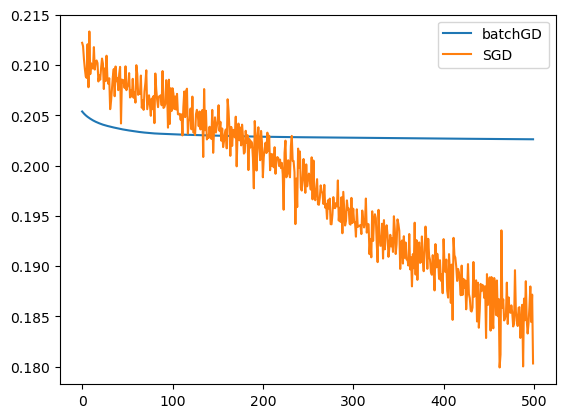

In [35]:
import matplotlib.pyplot as plt
plt.plot(history_batch.history['loss'] , label='batchGD')
plt.plot(history_sgd.history['loss'], label='SGD')
plt.legend()
plt.show() 

- This shows that the updates in BatchGD are smoother in comparison to the updates in weights in SGD.